# Product & Category Trends

Notebook นี้โฟกัสที่ **behavioral product dynamics** ของลูกค้า Instacart โดยตอบ 5 คำถามหลัก:

1. **Market Share & Category Dominance** — แต่ละ segment ใช้สัดส่วนกับหมวดไหนมากที่สุด
2. **Weekly Rhythm: DOW x Category Boom** — แต่ละวันของสัปดาห์มี category signature อย่างไร
3. **Order Sequence Evolution** — สินค้าไหนเป็น `Gateway` และสินค้าไหนกลายเป็น `Habit`
4. **Product Velocity & Decay** — สินค้าไหนมีรอบซื้อซ้ำเร็วและผูกกับ threshold `15 วัน`
5. **Basket Intensity & Cross-Selling** — ตะกร้าแน่นและหลากหลายที่สุดเมื่อไร

> หมายเหตุ: dataset นี้ไม่มีราคา/ยอดเงินต่อ SKU โดยตรง ดังนั้น notebook จะใช้ **order lines เป็น spend proxy** เวลาพูดถึง `share of wallet`

In [11]:
import importlib
import sys
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path

In [13]:
DATA_PATH = '../../data/processed/quality'

orders = pd.read_csv(Path(DATA_PATH) / 'orders_clean.csv')
order_products_prior = pd.read_csv(Path(DATA_PATH) / 'order_products_prior_clean.csv')
order_products_train = pd.read_csv(Path(DATA_PATH) / 'order_products_train_clean.csv')
products = pd.read_csv(Path(DATA_PATH) / 'products_clean.csv')
aisles = pd.read_csv(Path(DATA_PATH) / 'aisles_clean.csv')
department = pd.read_csv(Path(DATA_PATH) / 'departments_clean.csv')

tables = {
    'orders': orders,
    'order_products_prior': order_products_prior,
    'order_products_train': order_products_train,
    'products': products,
    'aisles': aisles,
    'departments': department,
}

df = tables['orders'].merge(tables['order_products_prior'], on='order_id')

# 2. ลำดับการ Merge ที่ถูกต้อง (จากเล็กไปใหญ่)
df = (
    df# ต้องดึง product_id ไปหา aisle_id และ department_id ก่อน
      .merge(tables['products'][['product_id', 'aisle_id', 'department_id']], on='product_id', how='left')
      # พอมี ID ครบแล้ว ค่อยไปดึง "ชื่อ" มาแปะ
      .merge(tables['aisles'][['aisle_id', 'aisle']], on='aisle_id', how='left')
      .merge(tables['departments'][['department_id', 'department']], on='department_id', how='left')
      # ลบคอลัมน์ ID ที่ไม่ใช้แล้วออกเพื่อประหยัด RAM
      .drop(columns=['aisle_id', 'department_id'])
)


## Analysis roadmap

- **Section 1**: Market Share & Category Dominance  
- **Section 2**: Weekly Rhythm — `DOW x Category Boom`  
- **Section 3**: Order Sequence Evolution — `Gateway vs Habit`  
- **Section 4**: Product Velocity & Decay — linked to the `15-day threshold`  
- **Section 5**: Basket Intensity & Cross-Selling

## 1) Market Share & Category Dominance

เริ่มจากดูว่าแต่ละ segment ใช้ `share of wallet proxy` ไปกับหมวดสินค้าไหนมากที่สุด โดยใน notebook นี้ใช้ **สัดส่วน order lines** แทนยอดใช้จ่ายจริง เพราะไม่มีข้อมูลราคาใน dataset

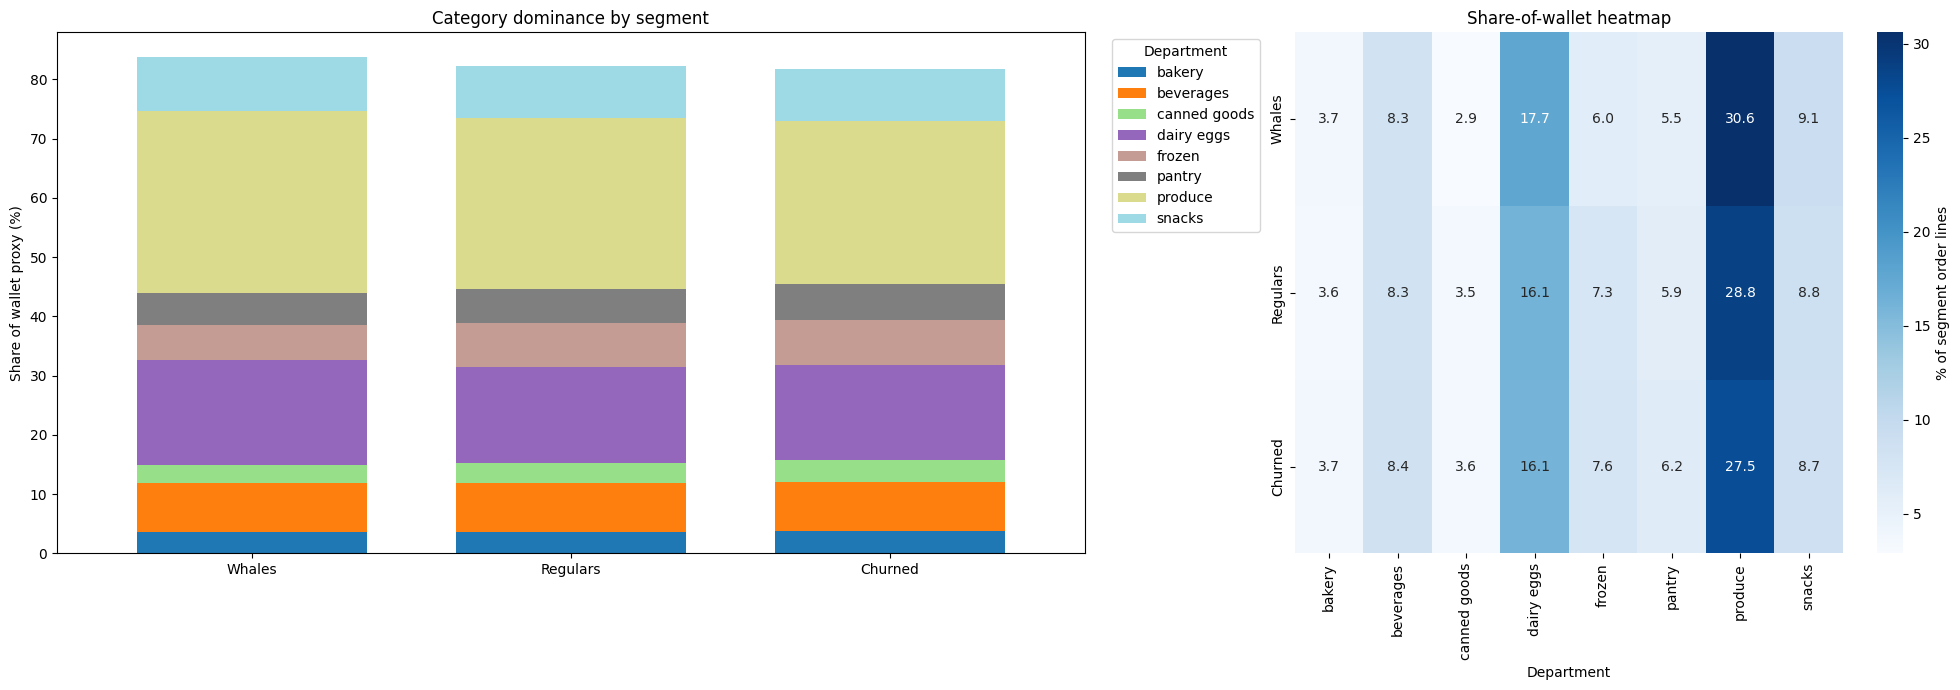

,segment,department,share_of_wallet_proxy
0,Whales,produce,30.602679
1,Whales,dairy eggs,17.745185
2,Whales,snacks,9.135736
3,Whales,beverages,8.251534
4,Whales,frozen,5.984658
5,Regulars,produce,28.803345
6,Regulars,dairy eggs,16.134179
7,Regulars,snacks,8.792928
8,Regulars,beverages,8.299004
9,Regulars,frozen,7.337706


- Whales: dominant category = produce (30.6% share-of-wallet proxy)
- Regulars: dominant category = produce (28.8% share-of-wallet proxy)
- Churned: dominant category = produce (27.5% share-of-wallet proxy)


In [23]:
# Make this section work even when the notebook imports the base tables directly
segment_order = ["Whales", "Regulars", "Churned"]
DOW_ORDER = ["Sun", "Mon", "Tue", "Wed", "Thu", "Fri", "Sat"]
TOP_N = 10

txn = df.copy()

# Add the missing fields required by downstream sections using map() for better speed/memory
if "product_name" not in txn.columns:
    product_name_map = (
        tables["products"][["product_id", "product_name"]]
        .drop_duplicates("product_id")
        .set_index("product_id")["product_name"]
    )
    txn["product_name"] = txn["product_id"].map(product_name_map)

if "order_date" not in txn.columns:
    candidate_paths = [
        Path("../../data/processed/features/orders_with_dates.csv"),
        Path("../data/processed/features/orders_with_dates.csv"),
        Path("data/processed/features/orders_with_dates.csv"),
    ]
    order_dates_path = next((p for p in candidate_paths if p.exists()), None)
    if order_dates_path is None:
        raise FileNotFoundError("orders_with_dates.csv not found in expected locations.")

    order_dates_df = pd.read_csv(order_dates_path)
    order_dates_df["order_date"] = pd.to_datetime(order_dates_df["order_date"])
    order_date_map = order_dates_df.drop_duplicates("order_id").set_index("order_id")["order_date"]
    txn["order_date"] = txn["order_id"].map(order_date_map)

dow_map = dict(enumerate(DOW_ORDER))
txn["day_name"] = pd.Categorical(
    txn["order_dow"].map(dow_map),
    categories=DOW_ORDER,
    ordered=True,
)

order_clock = (
    tables["orders"][["order_id", "user_id", "order_number", "days_since_prior_order"]]
    .sort_values(["user_id", "order_number"])
    .copy()
)
order_clock["days_since_prior_order"] = order_clock["days_since_prior_order"].fillna(0)
order_clock["relative_day"] = order_clock.groupby("user_id")["days_since_prior_order"].cumsum()
relative_day_map = order_clock.set_index("order_id")["relative_day"]
txn["relative_day"] = txn["order_id"].map(relative_day_map)

customer_profile = (
    txn.groupby("user_id", as_index=False)
    .agg(
        total_orders=("order_number", "max"),
        last_order_date=("order_date", "max"),
    )
)
# Match the original churn logic: advance the snapshot by 1 day so 31-day inactive users become Churned
snapshot_date = txn["order_date"].max() + pd.Timedelta(days=1)
customer_profile["days_since_last_order"] = (
    snapshot_date - customer_profile["last_order_date"]
).dt.days

whale_threshold = customer_profile["total_orders"].quantile(0.90)
customer_profile["segment"] = "Regulars"
customer_profile.loc[customer_profile["total_orders"] >= whale_threshold, "segment"] = "Whales"
customer_profile.loc[customer_profile["days_since_last_order"] > 30, "segment"] = "Churned"
customer_profile["segment"] = pd.Categorical(
    customer_profile["segment"],
    categories=segment_order,
    ordered=True,
)
segment_map = customer_profile.set_index("user_id")["segment"]
txn["segment"] = pd.Categorical(
    txn["user_id"].map(segment_map),
    categories=segment_order,
    ordered=True,
)

df = txn.copy()
top_departments = txn["department"].dropna().value_counts().head(8).index.tolist()

category_share = (
    txn.groupby(["segment", "department"], observed=True)
    .size()
    .rename("order_lines")
    .reset_index()
)
category_share["segment_total_lines"] = category_share.groupby("segment")["order_lines"].transform("sum")
category_share["share_of_wallet_proxy"] = (
    category_share["order_lines"] / category_share["segment_total_lines"] * 100
)

market_share_top = category_share[category_share["department"].isin(top_departments)].copy()
share_pivot = (
    market_share_top.pivot(index="segment", columns="department", values="share_of_wallet_proxy")
    .reindex(segment_order)
    .fillna(0)
)

fig, axes = plt.subplots(1, 2, figsize=(20, 7), gridspec_kw={"width_ratios": [1.5, 1]})
share_pivot.plot(kind="bar", stacked=True, ax=axes[0], width=0.72, colormap="tab20")
axes[0].set_title("Category dominance by segment")
axes[0].set_xlabel("")
axes[0].set_ylabel("Share of wallet proxy (%)")
axes[0].tick_params(axis="x", rotation=0)
axes[0].legend(title="Department", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=True)

sns.heatmap(
    share_pivot,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    ax=axes[1],
    cbar_kws={"label": "% of segment order lines"},
)
axes[1].set_title("Share-of-wallet heatmap")
axes[1].set_xlabel("Department")
axes[1].set_ylabel("")
plt.tight_layout()
plt.show()

category_leaders = (
    market_share_top.sort_values(["segment", "share_of_wallet_proxy"], ascending=[True, False])
    .groupby("segment")
    .head(5)
    [["segment", "department", "share_of_wallet_proxy"]]
    .reset_index(drop=True)
)

display(category_leaders)

for row in category_leaders.groupby("segment").head(1).itertuples(index=False):
    print(f"- {row.segment}: dominant category = {row.department} ({row.share_of_wallet_proxy:.1f}% share-of-wallet proxy)")

## 2) Weekly Rhythm: DOW x Category Boom

ส่วนนี้ใช้ `pd.crosstab(..., normalize='columns')` เพื่อดูว่าในแต่ละวันของสัปดาห์ หมวดไหนโดดเด่นกว่าปกติในแต่ละ segment

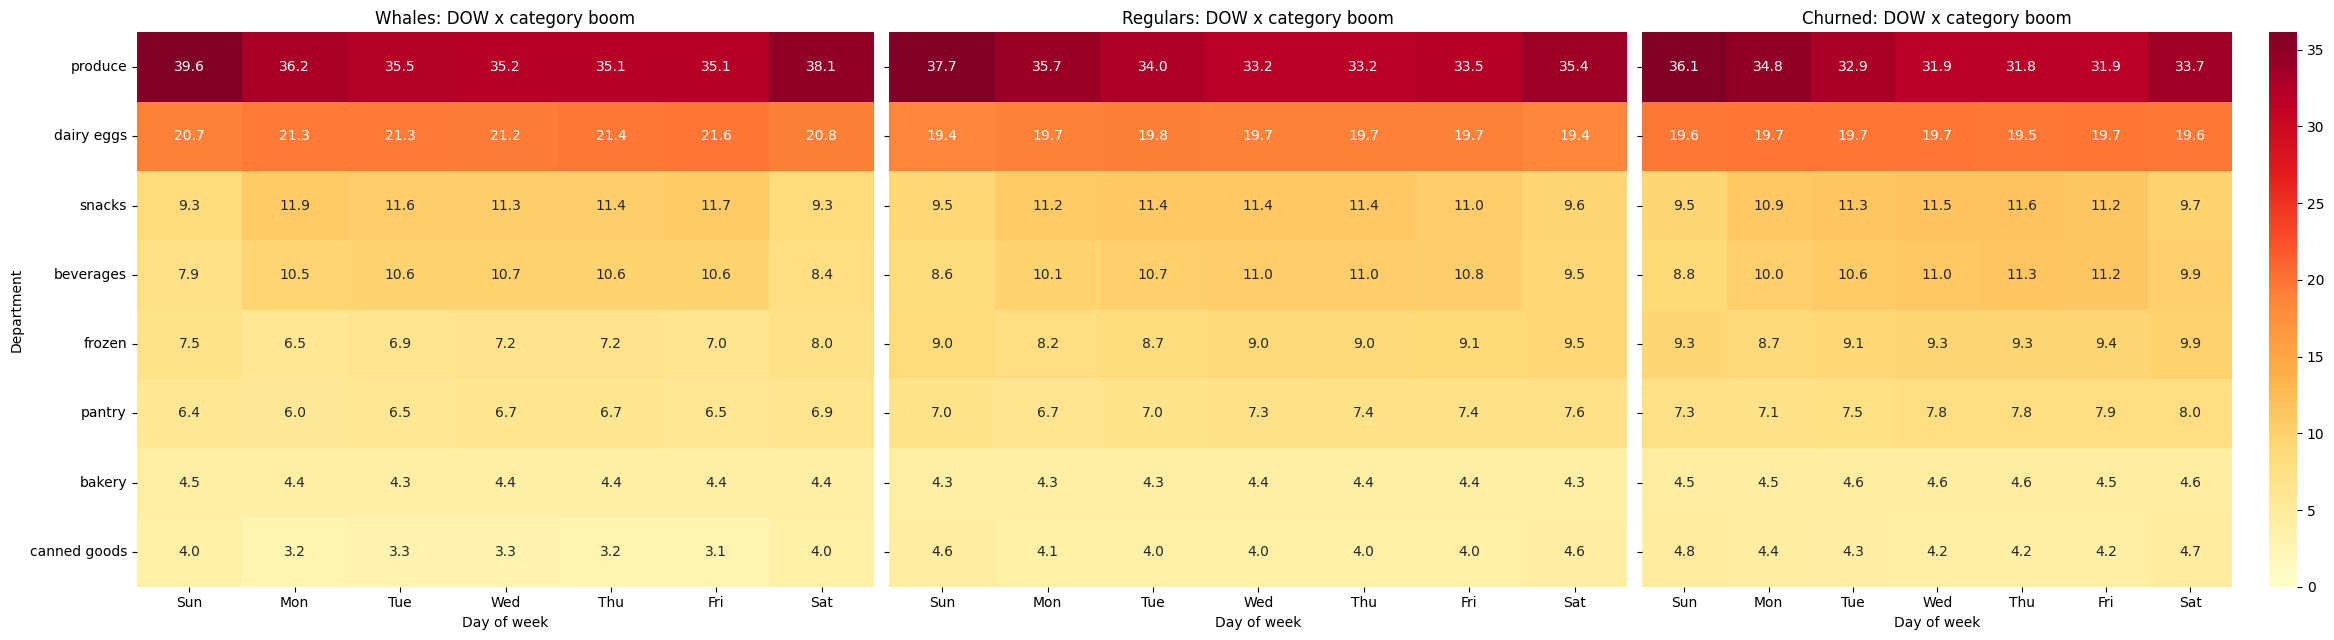

,segment,department,day_name,share_pct
0,Whales,bakery,Sun,4.478921
1,Whales,beverages,Wed,10.747133
2,Whales,canned goods,Sun,4.037766
3,Whales,dairy eggs,Fri,21.589021
4,Whales,frozen,Sat,8.013361
5,Whales,pantry,Sat,6.919845
6,Whales,produce,Sun,39.599973
7,Whales,snacks,Mon,11.889711
8,Regulars,bakery,Thu,4.378180
9,Regulars,beverages,Thu,10.981476


Example business use: deploy fresh/produce pushes on high-produce days and snack/beverage flash offers on their peak days.


In [24]:
weekly_focus = txn[txn["department"].isin(top_departments)].copy()

fig, axes = plt.subplots(1, 3, figsize=(24, 6.5), sharey=True)
for ax, seg in zip(axes, segment_order):
    seg_df = weekly_focus[weekly_focus["segment"] == seg]
    heat = pd.crosstab(seg_df["department"], seg_df["day_name"], normalize="columns") * 100
    heat = heat.reindex(index=top_departments, columns=DOW_ORDER).fillna(0)

    sns.heatmap(
        heat,
        annot=True,
        fmt=".1f",
        cmap="YlOrRd",
        ax=ax,
        cbar=ax is axes[-1],
        vmin=0,
    )
    ax.set_title(f"{seg}: DOW x category boom")
    ax.set_xlabel("Day of week")
    ax.set_ylabel("Department" if ax is axes[0] else "")
plt.tight_layout()
plt.show()

peak_day_by_category = (
    weekly_focus.groupby(["segment", "department", "day_name"], observed=True)
    .size()
    .rename("order_lines")
    .reset_index()
)
peak_day_by_category["day_total"] = peak_day_by_category.groupby(["segment", "day_name"])["order_lines"].transform("sum")
peak_day_by_category["share_pct"] = peak_day_by_category["order_lines"] / peak_day_by_category["day_total"] * 100
peak_day_by_category = (
    peak_day_by_category.sort_values(["segment", "department", "share_pct"], ascending=[True, True, False])
    .groupby(["segment", "department"])
    .head(1)
    [["segment", "department", "day_name", "share_pct"]]
    .reset_index(drop=True)
)

display(peak_day_by_category)
print("Example business use: deploy fresh/produce pushes on high-produce days and snack/beverage flash offers on their peak days.")

## 3) Order Sequence Evolution: Gateway vs Habit Products

เราจะเปรียบเทียบสินค้าที่เด่นใน `order_number == 1` กับสินค้าที่ share โตขึ้นในช่วง `order_number > 5` เพื่อดูทั้ง **สินค้าดึงลูกค้าเข้าบ้าน** และ **สินค้าที่ก่อให้เกิดนิสัยซื้อซ้ำ**

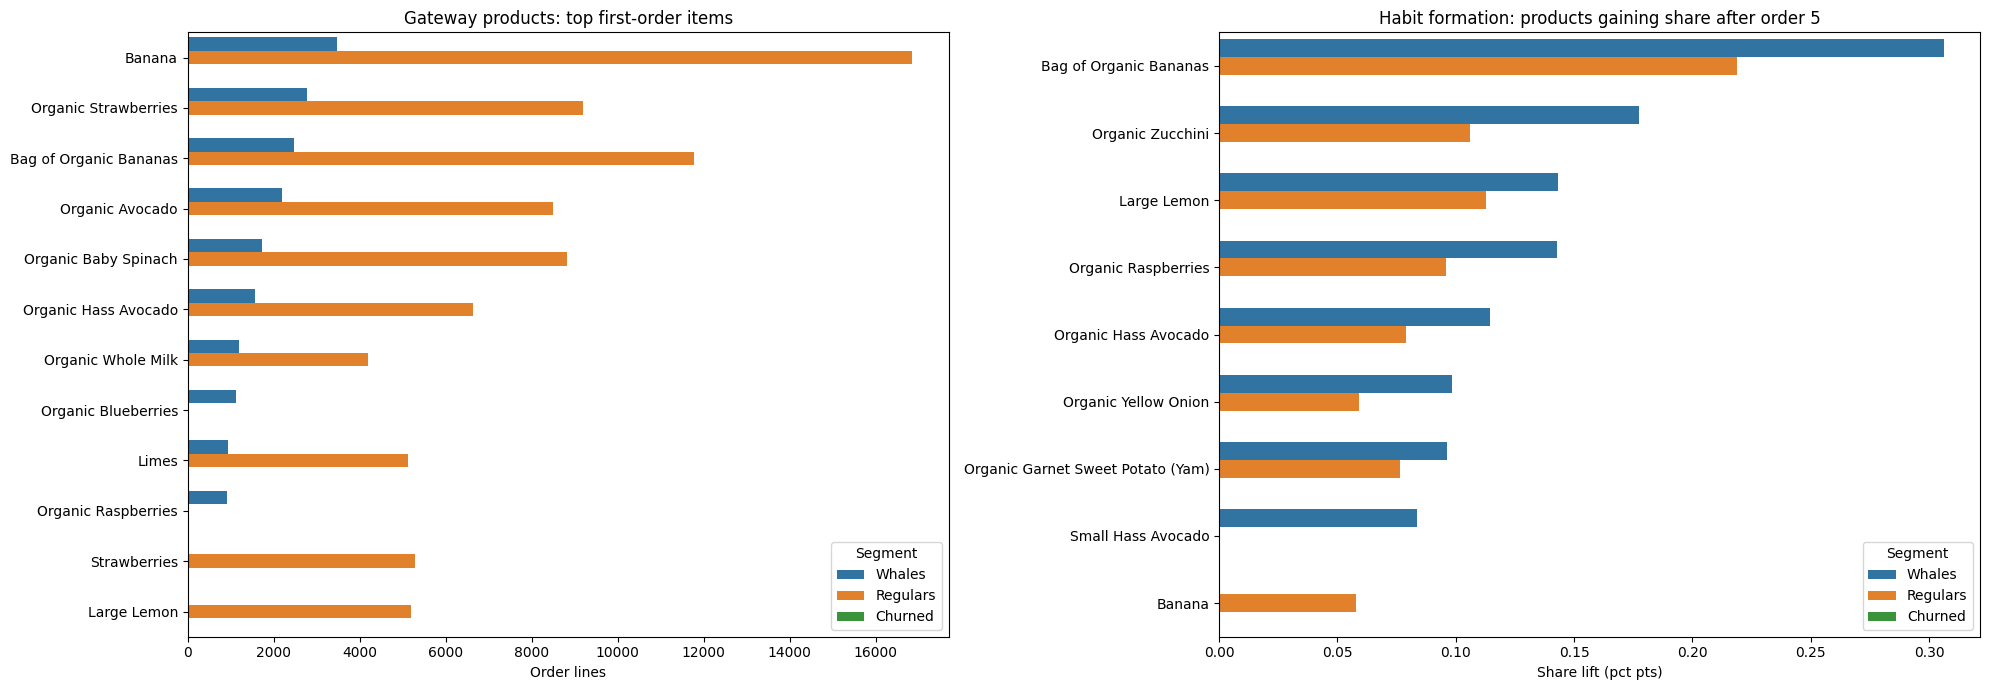

Gateway products by segment:


,segment,product_name,order_lines
0,Whales,Banana,3461
1,Whales,Organic Strawberries,2768
2,Whales,Bag of Organic Bananas,2478
3,Whales,Organic Avocado,2198
4,Whales,Organic Baby Spinach,1733
5,Whales,Organic Hass Avocado,1556
6,Whales,Organic Whole Milk,1200
7,Whales,Organic Blueberries,1131
8,Whales,Limes,939
9,Whales,Organic Raspberries,915


Habit products gaining share:


,segment,product_name,gateway_share,order_lines,habit_share,delta_habit_minus_gateway
0,Whales,Bag of Organic Bananas,1.113558,2478,1.419743,0.306185
1,Whales,Organic Zucchini,0.193232,430,0.370775,0.177542
2,Whales,Large Lemon,0.304678,678,0.448024,0.143345
3,Whales,Organic Raspberries,0.411181,915,0.554057,0.142876
4,Whales,Organic Hass Avocado,0.699232,1556,0.813616,0.114385
5,Whales,Organic Yellow Onion,0.306925,683,0.405251,0.098326
6,Whales,Organic Garnet Sweet Potato (Yam),0.103357,230,0.199837,0.096480
7,Whales,Small Hass Avocado,0.076394,170,0.160179,0.083785
8,Whales,Organic Baby Carrots,0.174808,389,0.256618,0.081810
9,Whales,Strawberries,0.349616,778,0.428834,0.079218


In [25]:
gateway_products = (
    txn.loc[txn["order_number"] == 1]
    .groupby(["segment", "product_name"], observed=False)
    .size()
    .rename("order_lines")
    .reset_index()
)
gateway_products["rank_in_segment"] = gateway_products.groupby("segment")["order_lines"].rank(method="first", ascending=False)
gateway_top = gateway_products[gateway_products["rank_in_segment"] <= TOP_N].sort_values(["segment", "rank_in_segment"])

journey_mix = (
    txn.assign(journey_stage=np.where(txn["order_number"] == 1, "Gateway (1st)", np.where(txn["order_number"] > 5, "Habit (6+)", "Early (2-5)")))
    .groupby(["segment", "journey_stage", "product_name"], observed=False)
    .size()
    .rename("order_lines")
    .reset_index()
)
journey_mix["stage_total"] = journey_mix.groupby(["segment", "journey_stage"])["order_lines"].transform("sum")
journey_mix["share_pct"] = journey_mix["order_lines"] / journey_mix["stage_total"] * 100

gateway_share = journey_mix[journey_mix["journey_stage"] == "Gateway (1st)"][["segment", "product_name", "share_pct", "order_lines"]].rename(columns={"share_pct": "gateway_share"})
habit_share = journey_mix[(journey_mix["journey_stage"] == "Habit (6+)") & (journey_mix["order_lines"] >= 5_000)][["segment", "product_name", "share_pct"]].rename(columns={"share_pct": "habit_share"})

habit_lift = gateway_share.merge(habit_share, on=["segment", "product_name"], how="inner")
habit_lift["delta_habit_minus_gateway"] = habit_lift["habit_share"] - habit_lift["gateway_share"]
habit_lift = habit_lift.sort_values(["segment", "delta_habit_minus_gateway"], ascending=[True, False])

plot_lift = habit_lift[habit_lift["segment"].isin(["Whales", "Regulars"])].groupby("segment").head(8).reset_index(drop=True)
fig, axes = plt.subplots(1, 2, figsize=(20, 7))
sns.barplot(
    data=gateway_top[gateway_top["segment"].isin(["Whales", "Regulars"])],
    x="order_lines",
    y="product_name",
    hue="segment",
    ax=axes[0],
)
axes[0].set_title("Gateway products: top first-order items")
axes[0].set_xlabel("Order lines")
axes[0].set_ylabel("")
axes[0].legend(title="Segment", loc="lower right")

sns.barplot(
    data=plot_lift,
    x="delta_habit_minus_gateway",
    y="product_name",
    hue="segment",
    ax=axes[1],
)
axes[1].set_title("Habit formation: products gaining share after order 5")
axes[1].set_xlabel("Share lift (pct pts)")
axes[1].set_ylabel("")
axes[1].legend(title="Segment", loc="lower right")
plt.tight_layout()
plt.show()

print("Gateway products by segment:")
display(gateway_top[["segment", "product_name", "order_lines"]].reset_index(drop=True))

print("Habit products gaining share:")
display(habit_lift.groupby("segment").head(10).reset_index(drop=True))

## 4) Product Velocity & Decay

ส่วนนี้วัดว่าแต่ละสินค้ามี **average days to reorder** เท่าไร และมีสัดส่วนการซื้อซ้ำภายใน `15 วัน` มากน้อยแค่ไหน เพื่อเชื่อมกับ recency threshold ที่ใช้จับสัญญาณเสี่ยง

/tmp/ipykernel_1077822/2094156683.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=velocity_focus.sort_values("median_days_to_reorder"), x="median_days_to_reorder", y="product_name", palette="crest", ax=axes[0])
/tmp/ipykernel_1077822/2094156683.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=velocity_focus.sort_values("repurchase_within_15_pct"), x="repurchase_within_15_pct", y="product_name", palette="flare", ax=axes[1])


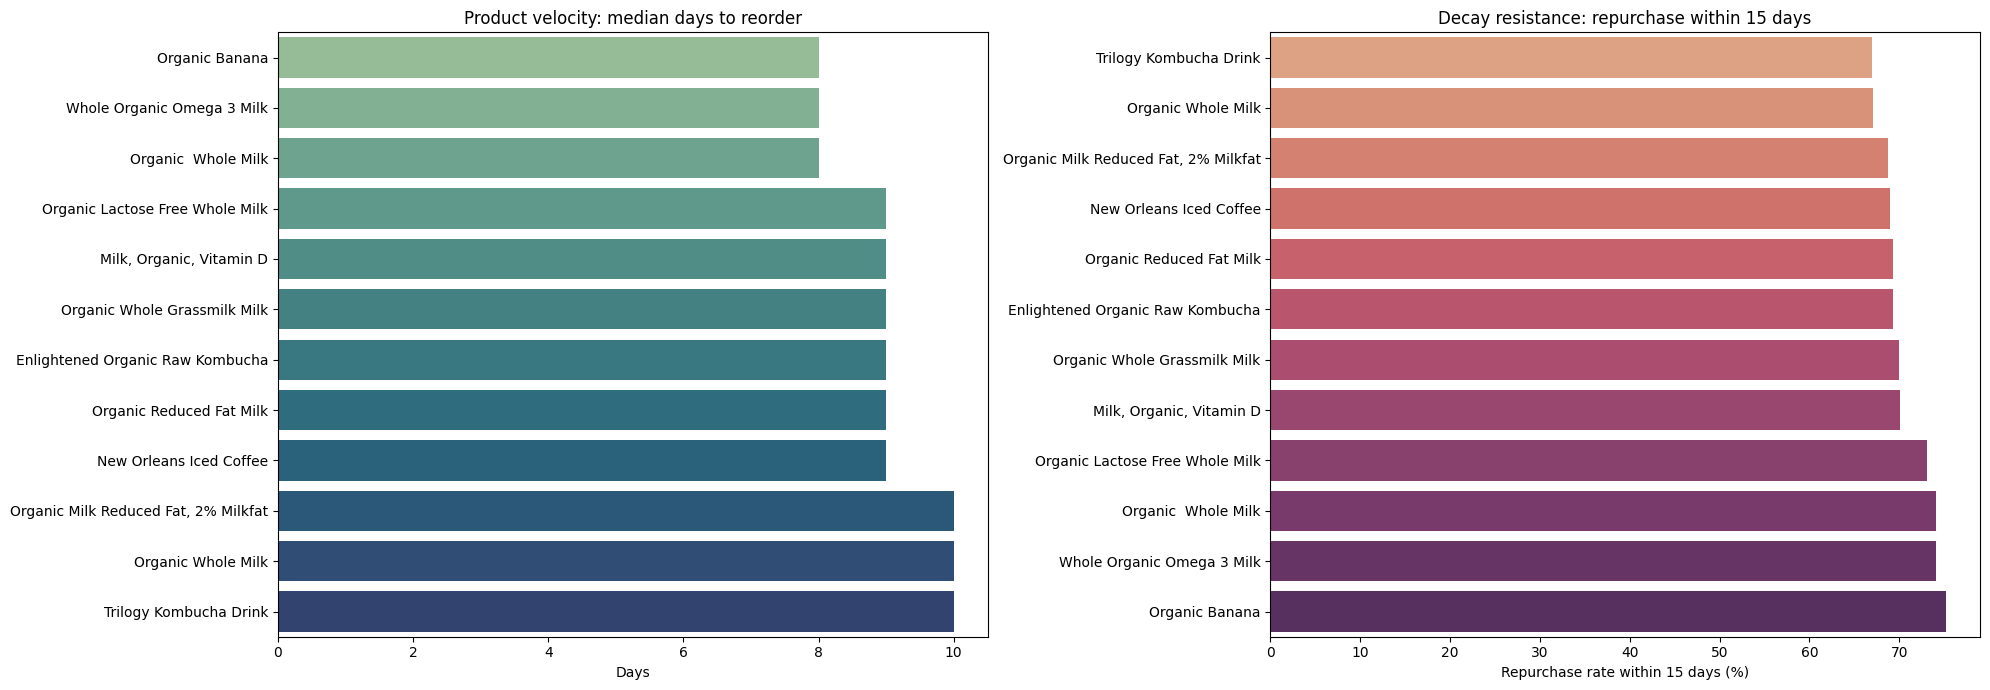

Top fast-repeat products:


,product_id,product_name,repeat_events,avg_days_to_reorder,median_days_to_reorder,repurchase_within_15_pct
0,37067,Organic Banana,11016,13.034495,8.0,75.217865
1,45504,Whole Organic Omega 3 Milk,7794,14.510008,8.0,74.056967
2,31720,Organic Whole Milk,8224,14.742218,8.0,74.039397
3,43394,Organic Lactose Free Whole Milk,7225,14.506851,9.0,73.038062
4,29447,"Milk, Organic, Vitamin D",17141,16.065515,9.0,70.089260
5,329,Organic Whole Grassmilk Milk,12237,16.767590,9.0,69.984473
6,19894,Enlightened Organic Raw Kombucha,5364,17.395600,9.0,69.295302
7,38689,Organic Reduced Fat Milk,30145,16.399536,9.0,69.251949
8,7521,New Orleans Iced Coffee,5488,17.576166,9.0,68.932216
9,13166,"Organic Milk Reduced Fat, 2% Milkfat",10605,17.205752,10.0,68.741160


Milk-related reorder cadence:


,product_id,product_name,repeat_events,avg_days_to_reorder,median_days_to_reorder,repurchase_within_15_pct
0,27845,Organic Whole Milk,113657,17.664772,10.0,67.102774
1,35951,Organic Unsweetened Almond Milk,43428,23.326126,14.0,55.017500
2,5785,Organic Reduced Fat 2% Milk,38251,19.403440,11.0,64.625761
3,24838,Unsweetened Almondmilk,37027,22.060064,13.0,57.603911
4,38689,Organic Reduced Fat Milk,30145,16.399536,9.0,69.251949
5,23909,2% Reduced Fat Milk,28435,19.762194,13.0,61.716195
6,4210,Whole Milk,27418,18.749070,11.0,64.698373
7,47144,Unsweetened Original Almond Breeze Almond Milk,24459,23.915491,14.0,53.976042
8,1463,Organic Milk,22550,18.533437,10.0,66.155211
9,432,Vanilla Almond Breeze Almond Milk,22370,23.746670,14.0,53.822083


Interpretation: if a short-cycle product like milk is not repurchased within ~15 days, it is a strong retention warning signal.


In [26]:
product_events = (
    txn[["user_id", "product_id", "product_name", "relative_day"]]
    .drop_duplicates()
    .sort_values(["user_id", "product_id", "relative_day"])
)
product_events["days_to_reorder"] = product_events.groupby(["user_id", "product_id"])["relative_day"].diff()
product_cycles = product_events.dropna(subset=["days_to_reorder"]).copy()

product_velocity = (
    product_cycles.groupby(["product_id", "product_name"], as_index=False)
    .agg(
        repeat_events=("days_to_reorder", "size"),
        avg_days_to_reorder=("days_to_reorder", "mean"),
        median_days_to_reorder=("days_to_reorder", "median"),
        repurchase_within_15_pct=("days_to_reorder", lambda s: (s <= 15).mean() * 100),
    )
)
velocity_focus = (
    product_velocity[product_velocity["repeat_events"] >= 5_000]
    .sort_values(["repurchase_within_15_pct", "repeat_events"], ascending=[False, False])
    .head(12)
)
milk_focus = (
    product_velocity[
        product_velocity["product_name"].str.contains("milk", case=False, na=False)
        & (product_velocity["repeat_events"] >= 5_000)
    ]
    .sort_values("repeat_events", ascending=False)
    .head(10)
)

fig, axes = plt.subplots(1, 2, figsize=(20, 7))
sns.barplot(data=velocity_focus.sort_values("median_days_to_reorder"), x="median_days_to_reorder", y="product_name", palette="crest", ax=axes[0])
axes[0].set_title("Product velocity: median days to reorder")
axes[0].set_xlabel("Days")
axes[0].set_ylabel("")

sns.barplot(data=velocity_focus.sort_values("repurchase_within_15_pct"), x="repurchase_within_15_pct", y="product_name", palette="flare", ax=axes[1])
axes[1].set_title("Decay resistance: repurchase within 15 days")
axes[1].set_xlabel("Repurchase rate within 15 days (%)")
axes[1].set_ylabel("")
plt.tight_layout()
plt.show()

print("Top fast-repeat products:")
display(velocity_focus.reset_index(drop=True))

print("Milk-related reorder cadence:")
display(milk_focus.reset_index(drop=True))
print("Interpretation: if a short-cycle product like milk is not repurchased within ~15 days, it is a strong retention warning signal.")

## 5) Basket Intensity & Cross-Selling

สุดท้ายดูว่าในแต่ละวันและแต่ละ segment ตะกร้าแน่นแค่ไหน (`items per basket`) และหลากหลายกี่ category (`unique categories per basket`) เพื่อหา timing ที่เหมาะกับการทำ bundle deal หรือ cross-sell

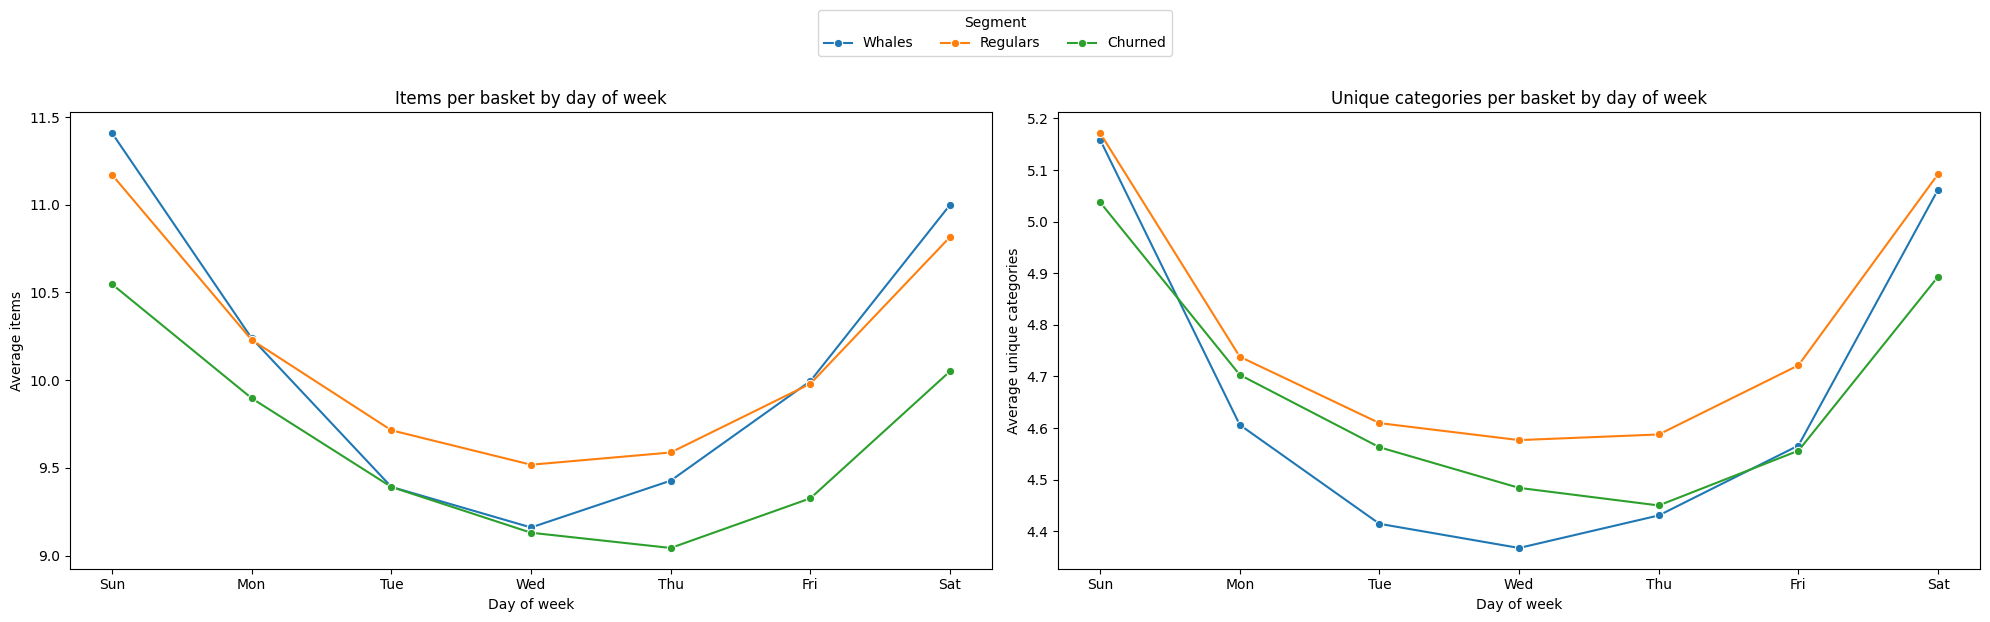

,segment,day_name,avg_items,avg_unique_categories
0,Whales,Sun,11.408471,5.158658
1,Regulars,Sun,11.170692,5.171477
2,Churned,Sun,10.546896,5.037397


Cross-sell implication: days with both larger baskets and more unique categories are the best windows for bundle deals and recommendation slots.


In [27]:
basket_metrics = (
    txn.groupby(["order_id", "segment", "day_name"], observed=True)
    .agg(
        items_per_basket=("product_id", "size"),
        unique_categories_per_basket=("department", "nunique"),
    )
    .reset_index()
)

basket_dow = (
    basket_metrics.groupby(["segment", "day_name"], observed=True)
    .agg(
        avg_items=("items_per_basket", "mean"),
        avg_unique_categories=("unique_categories_per_basket", "mean"),
    )
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(20, 6), sharex=True)
sns.lineplot(data=basket_dow, x="day_name", y="avg_items", hue="segment", marker="o", ax=axes[0])
axes[0].set_title("Items per basket by day of week")
axes[0].set_xlabel("Day of week")
axes[0].set_ylabel("Average items")

sns.lineplot(data=basket_dow, x="day_name", y="avg_unique_categories", hue="segment", marker="o", ax=axes[1])
axes[1].set_title("Unique categories per basket by day of week")
axes[1].set_xlabel("Day of week")
axes[1].set_ylabel("Average unique categories")

handles, labels = axes[0].get_legend_handles_labels()
for ax in axes:
    if ax.legend_ is not None:
        ax.legend_.remove()
fig.legend(handles, labels, title="Segment", loc="upper center", bbox_to_anchor=(0.5, 1.04), ncol=3, frameon=True)
fig.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

basket_peak = basket_dow.sort_values(["segment", "avg_items"], ascending=[True, False]).groupby("segment").head(1)
display(basket_peak.reset_index(drop=True))
print("Cross-sell implication: days with both larger baskets and more unique categories are the best windows for bundle deals and recommendation slots.")

## Executive takeaway

### What this notebook shows
- `Produce` and `dairy eggs` tend to dominate category share, but the mix shifts by segment and by day of week
- Some categories have strong **weekly signatures**, making them good candidates for timed promotions
- `Gateway` products are mostly essentials, while `Habit` products reveal where long-term trust and basket sophistication start to build
- Short-cycle staples with weak repurchase inside **15 days** are useful as early warning indicators
- Basket intensity is not constant through the week, which makes cross-sell timing a real lever

### Portfolio framing
- **Static profiling notebook** → who the customers are
- **This notebook** → how customer product choices evolve over time, across weekdays, and across reorder cycles